In [1]:
# PCA HANDS-ON CONDUCTED BY INTELLIPAAT

## **REQUIRED LIBRARIES:-**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

## **DATASET UPLOADING:-**

In [3]:
df=datasets.load_digits()

In [4]:
df

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

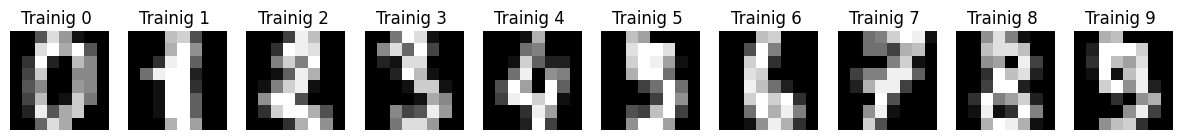

In [40]:
_,axes=plt.subplots(nrows=1,ncols=10,figsize=(15,5))

for ax,image,label in zip(axes,df.images,df.target):
  ax.set_axis_off()
  ax.imshow(image,cmap=plt.cm.grey,interpolation='nearest')
  ax.set_title("Trainig %i "%label)

In [5]:
x=df.data

In [6]:
x.shape

(1797, 64)

In [7]:
y=df.target

In [8]:
y

array([0, 1, 2, ..., 8, 9, 8])

In [9]:
y.shape

(1797,)

## **ML PROCESSES:-**

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
# stamderdization process:-
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

## **PCA PROCESS:-**

In [12]:
pca=PCA(n_components=20)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

In [13]:
x_train_pca.shape

(1437, 20)

In [14]:
x_test_pca.shape

(360, 20)

## **Logistic Regression:-**

In [15]:
model1=LogisticRegression()
model1.fit(x_train_pca,y_train)

LogisticRegression()

In [16]:
accuracy_score(y_test,model1.predict(x_test_pca))*100

94.44444444444444

## **Random Forest:-**

In [17]:
model2=RandomForestClassifier()
model2.fit(x_train_pca,y_train)

RandomForestClassifier()

In [18]:
accuracy_score(y_test,model2.predict(x_test_pca))*100

96.38888888888889

## **Decision Tree Classifier:-**

In [19]:
model3=DecisionTreeClassifier()
model3.fit(x_train_pca,y_train)

DecisionTreeClassifier()

In [20]:
accuracy_score(y_test,model3.predict(x_test_pca))*100

84.44444444444444

## ***RANDOM FOREST CLASSIFIER GIVING THE HIGHEST ACCURACY ON THR DATASET:-***

## **LDA PROCESS:-**

## LOGISTIC REGRESSION:-

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis(n_components=9)
lda.fit(x_train_scaled,y_train)
x_train_lda=lda.transform(x_train_scaled)
x_test_lda=lda.transform(x_test_scaled)
model1.fit(x_train_lda,y_train)
print(f'Accuracy score for {9} components:',accuracy_score(y_test,model1.predict(x_test_lda))*100)

Accuracy score for 9 components: 95.0


## RANDOM FOREST:-

In [30]:
lda=LinearDiscriminantAnalysis(n_components=9)
lda.fit(x_train_scaled,y_train)
x_train_lda=lda.transform(x_train_scaled)
x_test_lda=lda.transform(x_test_scaled)
model2.fit(x_train_lda,y_train)
print(f'Accuracy score for {9} components:',accuracy_score(y_test,model2.predict(x_test_lda))*100)

Accuracy score for 9 components: 95.27777777777777


## DECISION TREE:-

In [39]:
lda=LinearDiscriminantAnalysis(n_components=9)
lda.fit(x_train_scaled,y_train)
x_train_lda=lda.transform(x_train_scaled)
x_test_lda=lda.transform(x_test_scaled)
model3.fit(x_train_lda,y_train)
print(f'Accuracy score for {9} components:',accuracy_score(y_test,model3.predict(x_test_lda))*100)

Accuracy score for 9 components: 90.0


## ***STILL IN CASE OF LDA OPERARION  RANDOM FOREST CLASSIFIER DOMINATES.***